In [1]:
import numpy as np
from scipy.interpolate import interp1d
from scipy.stats import invgamma
from tqdm import tqdm
import matplotlib.pyplot as plt

# Functions

## Inverse gamma distribution

In [2]:
def sample_S(s=None, sk=None, prior=None, max_prior_iter=100000):
    """
    Draw samples of the bandpowers of S, p(S|s). This assumes that the conditional
    distributions for the bandpowers are uncorrelated with one another, i.e. the Fourier-
    space covariance S has no off-diagonals.

    Parameters:
        s (array_like):
            A set of real-space samples of the field, of shape
            `(Ntimes, Nfreq)`. This will be Fourier transformed.
            Alternatively, `sk` can be given.

        sk (array_like):
            A set of Fourier-space samples of the field, of shape
            `(Ntimes, Nfreq)`.  The monopole is expected to be at the center
            of the frequency axis, i.e. the frequency axis has been fftshifted.

        prior (array_like):
            Array of delta function prior values, used to set certain modes to a
            fixed value.
    """
    if s is None and sk is None:
        raise ValueError("Must pass in s (real space) or sk (Fourier space) vector.")

    if sk is None:
        axes = (1,)
        sk = np.fft.ifftshift(s, axes=axes)
        sk = np.fft.fftn(sk, axes=axes)
        sk = np.fft.fftshift(sk, axes=axes)
    Nobs, Nfreqs = sk.shape

    if prior is None:
        prior = np.zeros((2, Nfreqs), dtype=float)

    # The scale parameter for the inverse gamma distribution (beta) is
    # equivalent to (Ntimes - 1) times the variance over the time axis of the
    # delay spectrum of the Gaussian Constrained Realization of the EoR
    beta = np.sum(sk * sk.conj(), axis=0).real
    
    # The shape parameter (alpha) differs from that used in Eriksen et al. 2008
    # i.e. `alpha = Nobs/2 - 1` because our data vector is complex and has
    # twice as many numbers as a purely real data vector
    alpha = Nobs - 1.0

    # We obtain samples of the power spectrum (x) by instead sampling the random
    # variable y = x / beta and then obtain x via x = y * beta
    x = np.zeros(Nfreqs)
    for i in range(Nfreqs):
        if np.any(prior[:, i] > 0):

            # The pdf for a log-uniform prior is proportional to 1 / x.
            # Multiplying the inverse gamma likelihood by this prior results
            # in an additional factor of 1 / x which increases the effective
            # value of the shape parameter (alpha) by 1.  With a log-uniform
            # prior, we thus sample from an inverse gamma distribution with
            # shape parameter alpha + 1.
            
            x[i] = invgamma.rvs(a=alpha+1) * beta[i]
            outside_prior = x[i] > prior[0, i] or x[i] < prior[1, i]
            
            if outside_prior:
                prior_iter=0
                # Resample until we 
                # obtain a sample within the prior bounds or attemps become > max_prior_iter
                print("iteration: ", i)
                x_arr=[]
                # pbar=tqdm(total=max_prior_iter)
                while (x[i] > prior[0, i] or x[i] < prior[1, i]) and prior_iter<max_prior_iter:
                    x[i] = invgamma.rvs(a=alpha+1) * beta[i]
                    x_arr.append(x[i])
                    prior_iter+=1
                    # pbar.update(1)
                # pbar.close()
                print("Last sample: ",x_arr[-1])
                np.savetxt('/Users/user/Documents/Codes/hydra_sys_project1/hydra-pspec-systematic-multiplicative/test_files/divergence_tests/x_resamples',x_arr)
                if prior_iter>=max_prior_iter:
                    print("Priors: {}".format(prior[:,i]))
                    print("\nAlpha: {}, Beta: {}".format(alpha,beta[i]))
                    raise ValueError("Number of prior resamples exceeded max_prior_iter")
        else:
            x[i] = invgamma.rvs(a=alpha) * beta[i]

    return x


## ICDF sampler

In [167]:
def draw_icdf_samples(alpha, beta, x):
    cdf = invgamma.rvs(a=alpha+1) * beta
    cdf -= cdf.min() # shift minimum down to zero
    if cdf.max()==0.0:
        cdf /= (cdf.max()+1e-5) # rescale maximum to 1
    else:
        cdf /= cdf.max() # rescale maximum to 1

    # Remove duplicate entries in cdf so interpolator can work properly; 
    # tends to result in sample points near the extrema of the prior bounds anyway
    cdf_unique, idxs_unique = np.unique(cdf, return_index=True)
    u = np.random.uniform(high=cdf.max())
    # Draw sample using inversion sampling method
    # Note: Must use linear interpolation to avoid very bad interpolation results
    return interp1d(cdf_unique, x[idxs_unique], kind='linear')(u)

def inversion_sample_invgamma(s, prior, prior_min, prior_max, ngrid=120, sk=None,max_prior_iter=10000):
    """
    Draw a sample from an inverse gamma distribution using inversion 
    sampling between uniform prior bounds.
    
    This works by sampling the cdf of the inverse gamma distribution 
    on a (logarithmic) grid and then interpolating to convert a uniform 
    random draw into a random draw with the correct pdf.

    Parameters:
        alpha (float):
            Inverse gamma alpha parameter.
        beta (float):
            Inverse gamma beta (scale) parameter.
        prior_min (float):
            Minimum of the prior range.
        prior_max (float):
            Maximum of the prior range.
        ngrid (int):
            Number of sample points to use for interpolator.

    Returns:
        sample (float):
            Sample drawn from the inverse gamma distribution between the 
            specified prior bounds.
    """

    if sk is None:
        axes = (1,)
        sk = np.fft.ifftshift(s, axes=axes)
        sk = np.fft.fftn(sk, axes=axes)
        sk = np.fft.fftshift(sk, axes=axes)
    Nobs, Nfreqs = sk.shape
    alpha=Nobs-1
    beta = np.sum(sk * sk.conj(), axis=0).real
    # Sample cdf logarithmically between provided prior bounds
    x = np.logspace(np.log10(prior_min), np.log10(prior_max), ngrid)
    for i in range(Nfreqs):
        if np.any(prior[:, i] > 0):

            # The pdf for a log-uniform prior is proportional to 1 / x.
            # Multiplying the inverse gamma likelihood by this prior results
            # in an additional factor of 1 / x which increases the effective
            # value of the shape parameter (alpha) by 1.  With a log-uniform
            # prior, we thus sample from an inverse gamma distribution with
            # shape parameter alpha + 1.
            x[i] = draw_icdf_samples(alpha,beta[i], x)
            outside_prior = x[i] > prior[0, i] or x[i] < prior[1, i]
            
            if outside_prior:
                prior_iter=0
                # Resample until we 
                # obtain a sample within the prior bounds or attemps become > max_prior_iter
                print("iteration: ", i)
                x_arr=[]
                # pbar=tqdm(total=max_prior_iter)
                while (x[i] > prior[0, i] or x[i] < prior[1, i]) and prior_iter<max_prior_iter:
                    x[i] = draw_icdf_samples(cdf,alpha,beta[i])
                    x_arr.append(x[i])
                    prior_iter+=1
                    # pbar.update(1)
                # pbar.close()
                print("Last sample: ",x_arr[-1])
                if prior_iter>=max_prior_iter:
                    print("Priors: {}".format(prior[:,i]))
                    print("\nAlpha: {}, Beta: {}".format(alpha,beta[i]))
                    raise ValueError("Number of prior resamples exceeded max_prior_iter")
        else:
            x[i] = draw_icdf_samples(alpha,beta[i],x)

    return x

# Tests

## On s before sampler got stuck

### Loading data

In [157]:
'''Loading the EoR GCR solution before the sampler got stuck'''
'''RUN HYDRA BEFORE RUNNING THIS CELL'''
s = np.load('/Users/user/Documents/Codes/hydra_sys_project1/hydra-pspec-systematic-multiplicative/test_files/divergence_tests_airy_v2_1/eor-gcr.npy',allow_pickle=False)

In [158]:
'''Loading priors'''
priors=np.load('/Users/user/Documents/Codes/hydra_sys_project1/hydra-pspec-systematic-multiplicative/test_files/ps_prior.npy',allow_pickle=False)

### Drawing samples

In [159]:
N = 10000
alpha=202.0
beta=2.999806377899619e+32
samples_S = np.array([sample_S(s=s, prior=priors) for i in tqdm(range(N))]) #Needs original priors
priors=priors+0.0001 #shifting 0s for the log operaiton
samples_inversion = np.array([inversion_sample_invgamma(s, prior=priors, prior_min=priors[1,57], prior_max=priors[0,57]) for i in tqdm(range(N))])

100%|██████████| 10000/10000 [00:46<00:00, 213.81it/s]


In [160]:
print("Old sampler shape: {}, new sampler shape: {}".format(samples_S.shape, samples_inversion.shape))

Old sampler shape: (10000, 120), new sampler shape: (10000, 120)


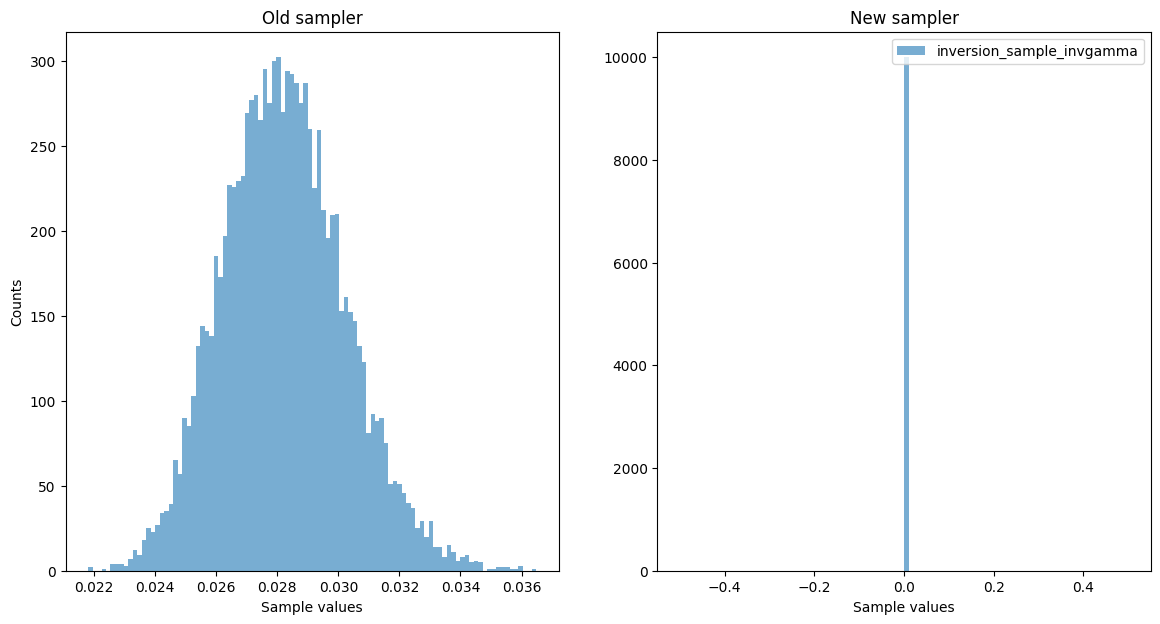

In [161]:
fig, ax = plt.subplots(1, 2, figsize=(14,7))
ax[0].hist(samples_S[:,57], bins=100, density=False, alpha=0.6, label="sample_S")
ax[1].hist(samples_inversion[:,57], bins=100, density=False, alpha=0.6, label="inversion_sample_invgamma")
plt.legend()
ax[0].set_title("Old sampler")
ax[1].set_title("New sampler")
ax[0].set_xlabel("Sample values")
ax[1].set_xlabel("Sample values")
ax[0].set_ylabel("Counts")
plt.show()

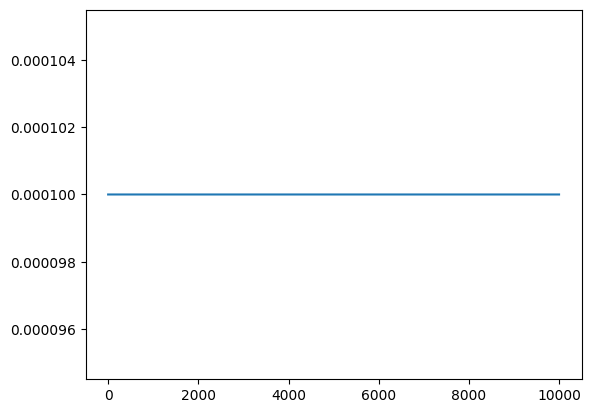

In [165]:
plt.plot(samples_inversion[:,57])

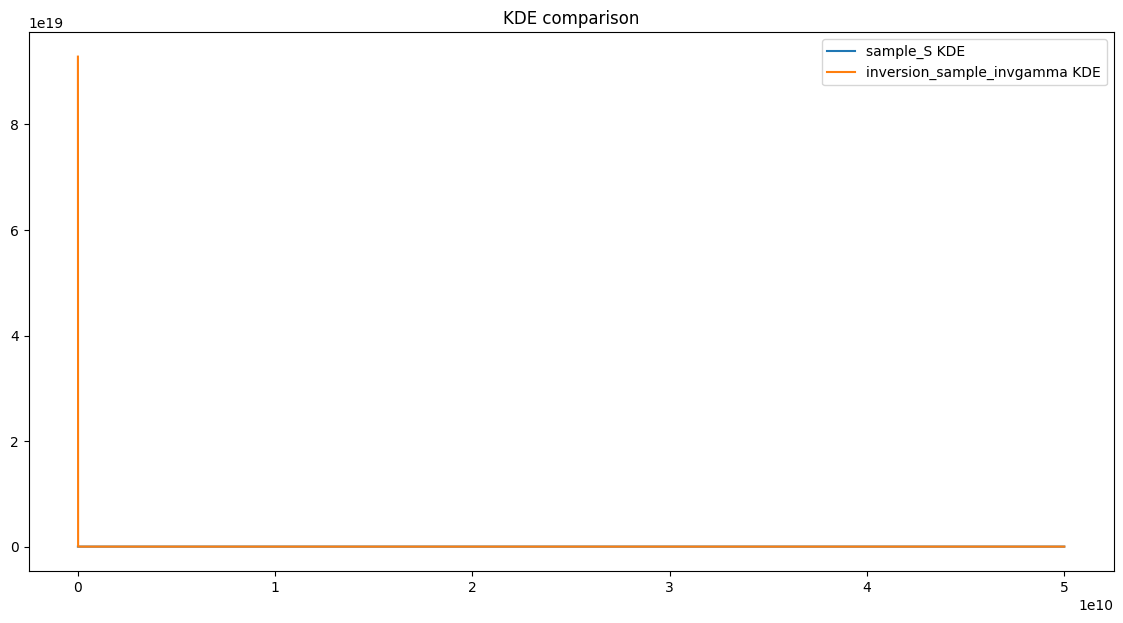

In [162]:
from scipy.stats import gaussian_kde

kde_1 = gaussian_kde(samples_S[:,57])
kde_2 = gaussian_kde(samples_inversion[:,57])
x_vals = np.linspace(priors[1,57], priors[0,57], N)
plt.figure(figsize=(14,7))
plt.plot(x_vals, kde_1(x_vals), label="sample_S KDE")
plt.plot(x_vals, kde_2(x_vals), label="inversion_sample_invgamma KDE")
plt.legend()
plt.title("KDE comparison")
plt.show()


In [163]:
from scipy.stats import ks_2samp

for i in range(120):
    ks_stat, ks_pval = ks_2samp(samples_S[:,i], samples_inversion[:,i])
    print("KS Statistic:", ks_stat)
    print("p-value:", ks_pval)

KS Statistic: 1.0
p-value: 0.0
KS Statistic: 1.0
p-value: 0.0
KS Statistic: 1.0
p-value: 0.0
KS Statistic: 1.0
p-value: 0.0
KS Statistic: 1.0
p-value: 0.0
KS Statistic: 1.0
p-value: 0.0
KS Statistic: 1.0
p-value: 0.0
KS Statistic: 1.0
p-value: 0.0
KS Statistic: 1.0
p-value: 0.0
KS Statistic: 1.0
p-value: 0.0
KS Statistic: 1.0
p-value: 0.0
KS Statistic: 1.0
p-value: 0.0
KS Statistic: 1.0
p-value: 0.0
KS Statistic: 1.0
p-value: 0.0
KS Statistic: 1.0
p-value: 0.0
KS Statistic: 1.0
p-value: 0.0
KS Statistic: 1.0
p-value: 0.0
KS Statistic: 1.0
p-value: 0.0
KS Statistic: 1.0
p-value: 0.0
KS Statistic: 1.0
p-value: 0.0
KS Statistic: 1.0
p-value: 0.0
KS Statistic: 1.0
p-value: 0.0
KS Statistic: 1.0
p-value: 0.0
KS Statistic: 1.0
p-value: 0.0
KS Statistic: 1.0
p-value: 0.0
KS Statistic: 1.0
p-value: 0.0
KS Statistic: 1.0
p-value: 0.0
KS Statistic: 1.0
p-value: 0.0
KS Statistic: 1.0
p-value: 0.0
KS Statistic: 1.0
p-value: 0.0
KS Statistic: 1.0
p-value: 0.0
KS Statistic: 1.0
p-value: 0.0
KS Stati

In [164]:
from scipy.stats import wasserstein_distance
wd = wasserstein_distance(samples_S[:,57], samples_inversion[:,57])
print("Wasserstein distance:", wd)

Wasserstein distance: 0.028129081486297235


## On s where sampler gets stuck

In [124]:
'''Loading data from the iteration where sampler got stuck'''
'''RUN HYDRA BEFORE RUNNING THIS CELL'''
s = np.load('/Users/user/Documents/Codes/hydra_sys_project1/hydra-pspec-systematic-multiplicative/test_files/divergence_tests_airy_v2_1/eor-gcr.npy',allow_pickle=False)
'''Loading priors and shifting 0s (for log ops)'''
priors=np.load('/Users/user/Documents/Codes/hydra_sys_project1/hydra-pspec-systematic-multiplicative/test_files/ps_prior.npy',allow_pickle=False)
priors=priors+0.0001

In [146]:
'''Running samplers'''
N = 10000
alpha=202.0
samples_inversion = np.array([inversion_sample_invgamma(s, priors, prior_min=priors[1,57], prior_max=priors[0,57]) for i in tqdm(range(N))])

100%|██████████| 10000/10000 [00:48<00:00, 207.86it/s]


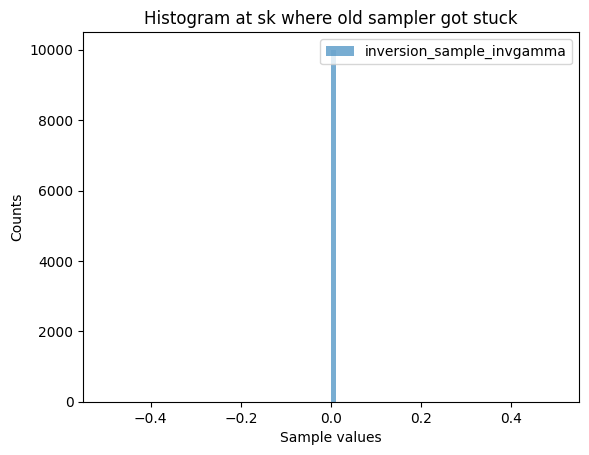

In [150]:
plt.hist(samples_inversion[:,0], bins=100, density=False, alpha=0.6, label="inversion_sample_invgamma")
plt.legend()
plt.xlabel("Sample values")
plt.ylabel("Counts")
plt.title("Histogram at sk where old sampler got stuck")
plt.show()


In [151]:
samples_inversion

array([[0.0001, 0.0001, 0.0001, ..., 0.0001, 0.0001, 0.0001],
       [0.0001, 0.0001, 0.0001, ..., 0.0001, 0.0001, 0.0001],
       [0.0001, 0.0001, 0.0001, ..., 0.0001, 0.0001, 0.0001],
       ...,
       [0.0001, 0.0001, 0.0001, ..., 0.0001, 0.0001, 0.0001],
       [0.0001, 0.0001, 0.0001, ..., 0.0001, 0.0001, 0.0001],
       [0.0001, 0.0001, 0.0001, ..., 0.0001, 0.0001, 0.0001]])